<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [4]:
# Write your code here
df.dtypes

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [6]:
df.count()

ResponseId             65437
MainBranch             65437
Age                    65437
Employment             65437
RemoteWork             54806
                       ...  
JobSatPoints_11        29445
SurveyLength           56182
SurveyEase             56238
ConvertedCompYearly    23435
JobSat                 29126
Length: 114, dtype: int64

In [7]:
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [11]:
# Write your code here}
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [12]:
# Write your code here
df["Country"].unique()

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
            

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [14]:
## Write your code here
country_counts = (
    df["Country"]
    .value_counts(dropna=False)
    .reset_index()
)

country_counts.head(20)

,Country,count
0,United States of America,11095
1,NaN,6507
2,Germany,4947
3,India,4231
4,United Kingdom of Great Britain and Northern I...,3224
5,Ukraine,2672
6,France,2110
7,Canada,2104
8,Poland,1534
9,Netherlands,1449


### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [15]:
## Write your code here
df["Employment"].value_counts(dropna=False)

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

In [16]:
employment_encoded = pd.get_dummies(
    df["Employment"],
    prefix="Employment"
)

In [17]:
employment_encoded.head()

,"Employment_Employed, full-time","Employment_Employed, full-time;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Employment_Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Employment_Student, full-time;Not employed, but looking for work;Retired","Employment_Student, full-time;Not employed, but looking for work;Student, part-time","Employment_Student, full-time;Retired","Employment_Student, full-time;Student, part-time","Employment_Student, full-time;Student, part-time;Employed, part-time","Employment_Student, full-time;Student, part-time;Retired","Employment_Student, part-time","Employment_Student, part-time;Employed, part-time","Employment_Student, part-time;Retired"
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [18]:
## Write your code here
missing_values = df.isnull().sum()

In [20]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values[missing_values > 0]

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
YearsCode                      5568
NEWSOSites                     5151
LearnCode                      4949
EdLevel                        4653
AISelect                       4530
Length: 109, dtype: int64

In [21]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
})

missing_report = (
    missing_report
    .sort_values("Missing Values", ascending=False)
)

missing_report[missing_report["Missing Values"] > 0]

,Missing Values,Missing %
AINextMuch less integrated,64289,98.245641
AINextLess integrated,63082,96.401119
AINextNo change,52939,80.900714
AINextMuch more integrated,51999,79.464217
EmbeddedAdmired,48704,74.428840
...,...,...
YearsCode,5568,8.508948
NEWSOSites,5151,7.871693
LearnCode,4949,7.563000
EdLevel,4653,7.110656


<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [22]:
## Write your code here

df["ConvertedCompYearly"].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

<Axes: >

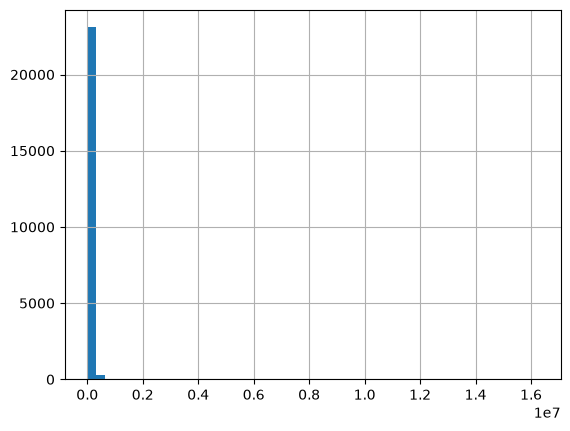

In [23]:
df["ConvertedCompYearly"].hist(bins=50)

In [24]:
df["ConvertedCompYearly"].fillna(
    df["ConvertedCompYearly"].median(),
    inplace=True
)

/tmp/ipykernel_955/1408569630.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["ConvertedCompYearly"].fillna(


0        65000.0
1        65000.0
2        65000.0
3        65000.0
4        65000.0
          ...   
65432    65000.0
65433    65000.0
65434    65000.0
65435    65000.0
65436    65000.0
Name: ConvertedCompYearly, Length: 65437, dtype: float64

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [25]:
## Write your code here
df["RemoteWork"].value_counts(dropna=False)

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: count, dtype: int64

In [26]:
remotework_mode = df["RemoteWork"].mode()[0]

print(remotework_mode)

Hybrid (some remote, some in-person)


In [27]:
df["RemoteWork"] = df["RemoteWork"].fillna(remotework_mode)

In [28]:
df["RemoteWork"].isna().sum()

np.int64(0)

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [29]:
## Write your code here

df["ConvertedCompYearly"].isna().sum()

np.int64(42002)

In [31]:
df["ConvertedCompYearly_MinMax"] = (
    (df["ConvertedCompYearly"] - df["ConvertedCompYearly"].min())
    / (df["ConvertedCompYearly"].max() - df["ConvertedCompYearly"].min())
)

In [32]:
print("Min:", df["ConvertedCompYearly_MinMax"].min())
print("Max:", df["ConvertedCompYearly_MinMax"].max())

Min: 0.0
Max: 1.0


<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [33]:
## Write your code here

import numpy as np

# Crear nueva columna transformada
df['ConvertedCompYearly_Log'] = np.log1p(df['ConvertedCompYearly'])

# Verificar resultados
df[['ConvertedCompYearly', 'ConvertedCompYearly_Log']].head()

,ConvertedCompYearly,ConvertedCompYearly_Log
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


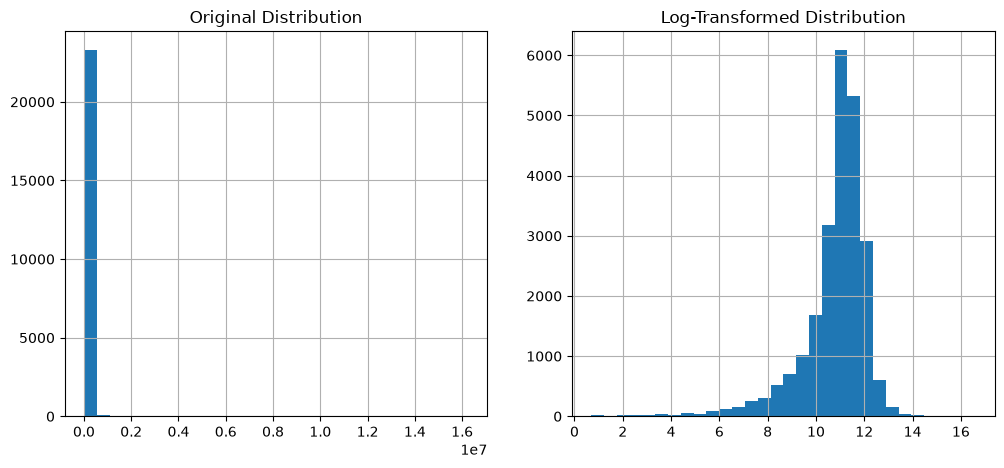

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['ConvertedCompYearly'].hist(bins=30)
plt.title('Original Distribution')

plt.subplot(1,2,2)
df['ConvertedCompYearly_Log'].hist(bins=30)
plt.title('Log-Transformed Distribution')

plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [35]:
## Write your code here

df['YearsCodePro'].unique()

<StringArray>
[                 nan,                 '17',                 '27',
                  '7',                 '11',                 '25',
                 '12',                 '10',                  '3',
   'Less than 1 year',                 '18',                 '37',
                 '15',                 '20',                  '6',
                  '2',                 '16',                  '8',
                 '14',                  '4',                 '45',
                  '1',                 '24',                 '29',
                  '5',                 '30',                 '26',
                  '9',                 '33',                 '13',
                 '35',                 '23',                 '22',
                 '31',                 '19',                 '21',
                 '28',                 '34',                 '32',
                 '40',                 '50',                 '39',
                 '44',                 '42',    

In [37]:
df['YearsCodePro'].isnull().sum()

np.int64(13827)

In [38]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

In [39]:
df['YearsCodePro'].isnull().sum()

np.int64(16733)

In [40]:
# Mostrar valores que no son números originalmente
df[df['YearsCodePro'].isnull()]['YearsCodePro'].head()

0   NaN
3   NaN
4   NaN
5   NaN
7   NaN
Name: YearsCodePro, dtype: float64

In [41]:
df['YearsCodePro'].apply(type).value_counts()

YearsCodePro
<class 'float'>    65437
Name: count, dtype: int64

In [43]:
median_years = df['YearsCodePro'].median()

df['YearsCodePro'] = df['YearsCodePro'].fillna(median_years)

In [44]:
df['YearsCodePro'].isnull().sum()

np.int64(0)

In [45]:
df['YearsCodePro'] = df['YearsCodePro'].astype(int)

In [46]:
df['YearsCodePro'].dtype

dtype('int64')

In [47]:
def experience_level(years):
    if years < 3:
        return 'Junior'
    elif years < 8:
        return 'Mid-Level'
    else:
        return 'Senior'

df['ExperienceLevel'] = df['YearsCodePro'].apply(experience_level)

In [48]:
df[['YearsCodePro', 'ExperienceLevel']].head(10)

,YearsCodePro,ExperienceLevel
0,8,Senior
1,17,Senior
2,27,Senior
3,8,Senior
4,8,Senior
5,8,Senior
6,7,Mid-Level
7,8,Senior
8,8,Senior
9,11,Senior


In [49]:
df['ExperienceLevel'].value_counts()

ExperienceLevel
Senior       42436
Mid-Level    16194
Junior        6807
Name: count, dtype: int64

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
